# 🏙️ PBL #2 — 1단계: 데이터 병합 및 전처리 (최종)
**서울시 청년 비만율 분석 | 하이파이브 팀**

## 📊 실행 결과 요약 (검증 완료)

| 항목 | 결과 |
|------|------|
| 입력 데이터 | 지역사회건강조사 7개년 원시자료 (2019~2025) |
| 서울 전체 응답자 | **160,434행** |
| 청년(19~39세) 필터 후 | 46,293행 |
| 최종 정제 데이터 | **45,621행** |
| 자치구 매핑 | 25개 전부 ✅ |
| 청년 비만율 | 27.3% |
| BMI 평균 | 23.19 |
| 잔여 결측 | 0개 |

## 🔍 연도별 변수 매핑 (실제 파일 확인하여 검증된 표)

| 표준 변수 | 2019 | 2020 | 2021 | 2022 | 2023 | 2024 | 2025 |
|----------|------|------|------|------|------|------|------|
| 시도코드 | `ctprvn_code` | `ctprvn_code` | `ctprvn_code` | `CTPRVN_CODE` | `CTPRVN_CODE` | `CTPRVN_CODE` | `CTPRVN_CODE` |
| 키 | `mea_14z1`(측정) | — | `oba_02z1` | `oba_02z1` | `oba_02z1` | `oba_02z1` | `oba_02z1` |
| 몸무게 | `mea_10z1`(측정) | — | `oba_03z1` | `oba_03z1` | `oba_03z1` | `oba_03z1` | `oba_03z1` |
| BMI | — | `oba_bmi` (계산됨) | — | — | — | — | — |
| 수면 | `mtc_01z1` | `mtc_17z1` | `mtc_17z1` | `mtc_17z1` | **없음** | `mtc_17z1` | `mtc_17z1` |
| 기타(걷기·아침식사·스트레스·우울·흡연·음주) | 전 연도 공통 변수 사용 |

# 0. 환경 설정

In [8]:
# !pip install pyreadstat

import pandas as pd
import numpy as np
import pyreadstat
import os, zipfile
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 60)

# 경로
ZIP_DIR = 'data/raw_sas/'      # zip 7개
SAS_DIR = 'data/raw_sas/'      # 자동 생성
OUT_DIR = 'data/processed/'    # 결과 저장
os.makedirs(SAS_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

ZIP_FILES = {
    2019:'chs19_all.zip', 2020:'chs20_all_re.zip', 2021:'chs21_all.zip',
    2022:'chs22_all.zip', 2023:'chs23_all.zip',    2024:'chs24_all.zip',
    2025:'chs25_all.zip',
}
print('✅ 설정 완료')

✅ 설정 완료


# 1. zip 압축 해제 → SAS 파일 확보

In [9]:
SAS_PATHS = {}
for year, fn in ZIP_FILES.items():
    zp = os.path.join(ZIP_DIR, fn)
    if not os.path.exists(zp):
        print(f'⚠️  {year}: zip 없음'); continue
    with zipfile.ZipFile(zp) as z:
        targets = [n for n in z.namelist()
                   if n.endswith('.sas7bdat') and 'ctv' not in n.lower()]
        if not targets: continue
        z.extract(targets[0], SAS_DIR)
        SAS_PATHS[year] = os.path.join(SAS_DIR, targets[0])
    print(f'✅ {year}: {targets[0]}')
print(f'\n총 {len(SAS_PATHS)}개 연도 준비 완료')

✅ 2019: chs19_all.sas7bdat
✅ 2020: chs20_all_re.sas7bdat
✅ 2021: chs21_all.sas7bdat
✅ 2022: chs22_all.sas7bdat
✅ 2023: chs23_all.sas7bdat
✅ 2024: chs24_all.sas7bdat
✅ 2025: chs25_all.sas7bdat

총 7개 연도 준비 완료


## 1-1. SAS 파일 내용 확인 함수 (선택)
컬럼명을 모를 때, 한글 라벨로 변수를 검색하는 헬퍼 함수입니다.

In [10]:
def peek_columns(year, keyword=None, n=50):
    """SAS 파일 컬럼명+한글라벨 출력. keyword로 필터 가능"""
    df, meta = pyreadstat.read_sas7bdat(SAS_PATHS[year], row_limit=5)
    print(f'=== {year}년 | 총 {len(meta.column_names)}개 컬럼 ===')
    cnt = 0
    for c, l in zip(meta.column_names, meta.column_labels):
        if keyword and not (l and keyword in l): continue
        print(f'  {c:14s} | {l}')
        cnt += 1
        if cnt >= n: break

# 예: peek_columns(2022, '신체활동')

# 2. 연도별 변수 매핑 (검증 완료)

In [11]:
VAR_MAP = {
    # 공통
    'age':       {y:'age'         for y in range(2019,2026)},
    'sex':       {y:'sex'         for y in range(2019,2026)},
    'sigungu':   {y:'signgu_code' for y in range(2019,2026)},

    # 시도코드 — 2019~2021 소문자, 2022~ 대문자
    'sido':      {2019:'ctprvn_code', 2020:'ctprvn_code', 2021:'ctprvn_code',
                  2022:'CTPRVN_CODE', 2023:'CTPRVN_CODE',
                  2024:'CTPRVN_CODE', 2025:'CTPRVN_CODE'},

    # 비만 핵심 (연도별 상이)
    'height':    {2019:'mea_14z1',
                  2021:'oba_02z1', 2022:'oba_02z1', 2023:'oba_02z1',
                  2024:'oba_02z1', 2025:'oba_02z1'},
    'weight':    {2019:'mea_10z1',
                  2021:'oba_03z1', 2022:'oba_03z1', 2023:'oba_03z1',
                  2024:'oba_03z1', 2025:'oba_03z1'},
    'bmi_given': {2020:'oba_bmi'},

    # 공통 변수
    'walk_days': {y:'phb_01z1' for y in range(2019,2026)},
    'breakfast': {y:'nua_01z2' for y in range(2019,2026)},
    'stress':    {y:'mta_01z1' for y in range(2019,2026)},
    'depress':   {y:'mtb_01z1' for y in range(2019,2026)},
    'smoke':     {y:'sma_03z2' for y in range(2019,2026)},
    'drink_freq':{y:'drb_01z3' for y in range(2020,2026)},  # 2019년은 변수명 다름→제외

    # 수면 — 2019는 mtc_01z1, 2023은 없음, 나머지는 mtc_17z1
    'sleep':     {2019:'mtc_01z1',
                  2020:'mtc_17z1', 2021:'mtc_17z1', 2022:'mtc_17z1',
                  2024:'mtc_17z1', 2025:'mtc_17z1'},
}

# 컬럼 존재 검증
YEAR_COLS = {}
for y, p in SAS_PATHS.items():
    _, meta = pyreadstat.read_sas7bdat(p, row_limit=1)
    YEAR_COLS[y] = set(meta.column_names)

print('변수 매핑 검증:')
for std, ymap in VAR_MAP.items():
    parts = []
    for y in sorted(SAS_PATHS):
        col = ymap.get(y)
        if col is None: parts.append(f'{y}=N/A')
        elif col in YEAR_COLS[y]: parts.append(f'{y}=✓')
        else: parts.append(f'{y}=✗')
    print(f'  {std:11s} | {" ".join(parts)}')

변수 매핑 검증:
  age         | 2019=✓ 2020=✓ 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  sex         | 2019=✓ 2020=✓ 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  sigungu     | 2019=✓ 2020=✓ 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  sido        | 2019=✓ 2020=✓ 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  height      | 2019=✓ 2020=N/A 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  weight      | 2019=✓ 2020=N/A 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  bmi_given   | 2019=N/A 2020=✓ 2021=N/A 2022=N/A 2023=N/A 2024=N/A 2025=N/A
  walk_days   | 2019=✓ 2020=✓ 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  breakfast   | 2019=✓ 2020=✓ 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  stress      | 2019=✓ 2020=✓ 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  depress     | 2019=✓ 2020=✓ 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  smoke       | 2019=✓ 2020=✓ 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  drink_freq  | 2019=N/A 2020=✓ 2021=✓ 2022=✓ 2023=✓ 2024=✓ 2025=✓
  sleep       | 2019=✓ 2020=✓ 2021=✓ 2022=✓ 2023=N/A 2024=✓ 2025=✓


# 3. 연도별 로드 + 서울 필터 + 표준화

In [12]:
def load_year(year):
    """해당 연도 SAS를 읽어 표준 컬럼명 DataFrame 반환 (서울 필터링까지)"""
    needed = {}
    for std, ymap in VAR_MAP.items():
        col = ymap.get(year)
        if col and col in YEAR_COLS[year]:
            needed[col] = std

    df, _ = pyreadstat.read_sas7bdat(SAS_PATHS[year], usecols=list(needed.keys()))
    df = df.rename(columns=needed)
    df['year'] = year
    df['sido'] = df['sido'].astype(str).str.strip().str.replace('.0','', regex=False)
    df = df[df['sido']=='11'].copy()
    return df

frames = []
for y in sorted(SAS_PATHS):
    d = load_year(y)
    print(f'  {y}: 서울 {len(d):,}행')
    frames.append(d)

df_raw = pd.concat(frames, ignore_index=True)
print(f'\n📦 병합 완료: {df_raw.shape[0]:,}행 × {df_raw.shape[1]}열')

  2019: 서울 22,930행
  2020: 서울 22,915행
  2021: 서울 22,923행
  2022: 서울 22,943행
  2023: 서울 22,928행
  2024: 서울 22,906행
  2025: 서울 22,889행

📦 병합 완료: 160,434행 × 15열


# 4. 전처리
## 4-1. 청년(19~39세) 필터

In [13]:
before = len(df_raw)
df = df_raw[(df_raw['age']>=19) & (df_raw['age']<=39)].copy()
print(f'청년 필터: {before:,} → {len(df):,}행')
print('\n연도별 청년 행 수:')
print(df['year'].value_counts().sort_index())

청년 필터: 160,434 → 46,293행

연도별 청년 행 수:
year
2019    6805
2020    7110
2021    6933
2022    6582
2023    6453
2024    6304
2025    6106
Name: count, dtype: int64


## 4-2. 결측 특수코드 → NaN
지역사회건강조사는 결측을 NaN이 아닌 특수코드(77/88/99/99999 등)로 표현합니다.

In [14]:
# ① 연속형: 큰 결측코드 + 비현실값
for col in ['height','weight','bmi_given']:
    if col in df.columns:
        df[col] = df[col].replace([9999,99999,8888,88888,7777,77777], np.nan)
        df.loc[df[col]>=900, col] = np.nan

# ② 빈도형: 77/88/99
for col in ['walk_days','sleep','breakfast','drink_freq']:
    if col in df.columns:
        df[col] = df[col].replace([77,88,99], np.nan)

# ③ 범주형: 7/8/9
for col in ['smoke','stress','depress']:
    if col in df.columns:
        df[col] = df[col].replace([7,8,9], np.nan)

miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
print('결측 변환 후 현황:')
display(pd.DataFrame({'결측수':miss, '결측률(%)':miss_pct})[miss>0].sort_values('결측률(%)', ascending=False))

결측 변환 후 현황:


,결측수,결측률(%)
bmi_given,39268,84.8
smoke,32564,70.3
weight,7644,16.5
height,7501,16.2
drink_freq,6805,14.7
sleep,6465,14.0
walk_days,1,0.0
depress,6,0.0
stress,3,0.0


## 4-3. BMI 계산

In [15]:
df['BMI'] = np.nan
m = df['height'].notna() & df['weight'].notna()
df.loc[m, 'BMI'] = df.loc[m, 'weight'] / (df.loc[m, 'height']/100)**2

if 'bmi_given' in df.columns:
    df['BMI'] = df['BMI'].fillna(df['bmi_given'])
df['BMI'] = df['BMI'].round(2)

print(f'BMI 계산 완료 — 결측: {df["BMI"].isna().sum():,}행')
print(df['BMI'].describe().round(2))

BMI 계산 완료 — 결측: 657행
count    45636.00
mean        23.22
std          4.36
min         10.22
25%         20.31
50%         22.59
75%         25.32
max        189.80
Name: BMI, dtype: float64


## 4-4. 이상치 처리

BMI Q1=20.3, Q3=25.3, IQR=5.0
이상치 제거: 46,293 → 45,621행


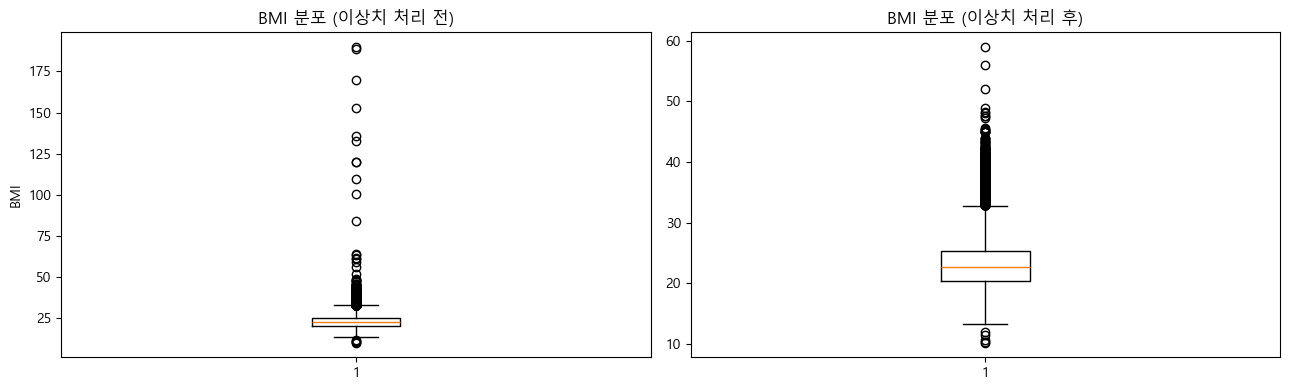

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].boxplot(df['BMI'].dropna())
axes[0].set_title('BMI 분포 (이상치 처리 전)')
axes[0].set_ylabel('BMI')

Q1, Q3 = df['BMI'].quantile([0.25, 0.75])
print(f'BMI Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={Q3-Q1:.1f}')

# 비만 분석이므로 IQR 컷은 부적절(고BMI 손실). 생물학적 불가능 범위만 제거
before = len(df)
df = df[(df['BMI']>=10) & (df['BMI']<=60)].copy()
print(f'이상치 제거: {before:,} → {len(df):,}행')

axes[1].boxplot(df['BMI'].dropna())
axes[1].set_title('BMI 분포 (이상치 처리 후)')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_bmi_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
df['비만여부'] = (df['BMI']>=25).astype(int)
df['BMI범주'] = pd.cut(df['BMI'],
    bins=[0,18.5,23,25,30,100],
    labels=['저체중','정상','과체중','비만1단계','비만2단계이상'])

print('BMI 범주 분포:')
print(df['BMI범주'].value_counts())
print(f'\n청년 비만율: {df["비만여부"].mean()*100:.1f}%')

BMI 범주 분포:
BMI범주
정상         21260
비만1단계       9659
과체중         8391
저체중         3598
비만2단계이상     2713
Name: count, dtype: int64

청년 비만율: 27.3%


## 4-5. 자치구 코드 매핑

In [18]:
GU_MAP = {
    '11110':'종로구','11140':'중구','11170':'용산구','11200':'성동구',
    '11215':'광진구','11230':'동대문구','11260':'중랑구','11290':'성북구',
    '11305':'강북구','11320':'도봉구','11350':'노원구','11380':'은평구',
    '11410':'서대문구','11440':'마포구','11470':'양천구','11500':'강서구',
    '11530':'구로구','11545':'금천구','11560':'영등포구','11590':'동작구',
    '11620':'관악구','11650':'서초구','11680':'강남구','11710':'송파구',
    '11740':'강동구',
}
df['sigungu'] = df['sigungu'].astype(str).str.strip().str.replace('.0','', regex=False)
df['자치구'] = df['sigungu'].map(GU_MAP)

unmapped = df[df['자치구'].isna()]['sigungu'].unique()
print(f'매핑된 자치구: {df["자치구"].nunique()}개')
print(f'매핑 실패: {len(unmapped)}개' + (f' → {unmapped[:5]}' if len(unmapped) else ''))

매핑된 자치구: 25개
매핑 실패: 0개


## 4-6. 잔여 결측 대체

In [19]:
# 빈도/연속형 → 중앙값
for v in ['walk_days','sleep','breakfast','drink_freq']:
    if v in df.columns and df[v].notna().any():
        df[v] = df[v].fillna(df[v].median())

# 범주형 → 최빈값
for v in ['smoke','stress','depress']:
    if v in df.columns and df[v].notna().any():
        df[v] = df[v].fillna(df[v].mode()[0])

print(f'잔여 결측: {df.isnull().sum().sum()}개')

잔여 결측: 52646개


# 5. 최종 저장

In [20]:
keep = ['year','자치구','sigungu','age','sex','BMI','BMI범주','비만여부',
        'walk_days','sleep','breakfast','stress','smoke','drink_freq','depress']
keep = [c for c in keep if c in df.columns]
df_final = df[keep].copy()

# 개인 수준 저장
df_final.to_csv(OUT_DIR + 'seoul_youth_individual.csv',
                index=False, encoding='utf-8-sig')

# 자치구×연도 집계
agg = df_final.groupby(['자치구','year']).agg(
    표본수       = ('비만여부','size'),
    비만율       = ('비만여부','mean'),
    평균BMI      = ('BMI','mean'),
    평균걷기일수 = ('walk_days','mean'),
    평균수면     = ('sleep','mean'),
    평균아침식사 = ('breakfast','mean'),
    흡연율       = ('smoke', lambda x: (x==1).mean()),
).reset_index()
agg['비만율']   = (agg['비만율']*100).round(2)
agg['평균BMI'] = agg['평균BMI'].round(2)
agg.to_csv(OUT_DIR + 'seoul_youth_district_year.csv',
           index=False, encoding='utf-8-sig')

print('='*55)
print(f'✅ 전처리 완료 — 최종 {len(df_final):,}행')
print('='*55)
print(f'자치구 수      : {df_final["자치구"].nunique()}개')
print(f'연도 범위      : {df_final["year"].min()}~{df_final["year"].max()}')
print(f'청년 비만율    : {df_final["비만여부"].mean()*100:.1f}%')
print(f'BMI 평균       : {df_final["BMI"].mean():.2f}')
print(f'잔여 결측 합계 : {df_final.isnull().sum().sum()}')
print(f'\n💾 저장:')
print(f'  {OUT_DIR}seoul_youth_individual.csv      ({df_final.shape})')
print(f'  {OUT_DIR}seoul_youth_district_year.csv   ({agg.shape})')

✅ 전처리 완료 — 최종 45,621행
자치구 수      : 25개
연도 범위      : 2019~2025
청년 비만율    : 27.3%
BMI 평균       : 23.19
잔여 결측 합계 : 0

💾 저장:
  data/processed/seoul_youth_individual.csv      ((45621, 15))
  data/processed/seoul_youth_district_year.csv   ((175, 9))


In [21]:
# 미리보기
print('▼ 개인 수준 데이터 (상위 5행)')
display(df_final.head())

print('\n▼ 자치구×연도 집계 (비만율 상위 10개)')
display(agg.sort_values('비만율', ascending=False).head(10))

▼ 개인 수준 데이터 (상위 5행)


,year,자치구,sigungu,age,sex,BMI,BMI범주,비만여부,walk_days,sleep,breakfast,stress,smoke,drink_freq,depress
3,2019,마포구,11440,27.0,1.0,21.53,정상,0,7.0,7.0,1.0,2.0,3.0,4.0,2.0
9,2019,마포구,11440,22.0,1.0,25.12,비만1단계,1,7.0,8.0,4.0,3.0,3.0,4.0,2.0
14,2019,마포구,11440,36.0,1.0,23.25,과체중,0,7.0,6.0,1.0,3.0,3.0,4.0,2.0
15,2019,마포구,11440,33.0,2.0,21.02,정상,0,7.0,7.0,4.0,3.0,3.0,4.0,2.0
19,2019,마포구,11440,23.0,1.0,20.62,정상,0,7.0,6.0,4.0,2.0,3.0,4.0,2.0



▼ 자치구×연도 집계 (비만율 상위 10개)


,자치구,year,표본수,비만율,평균BMI,평균걷기일수,평균수면,평균아침식사,흡연율
64,도봉구,2020,250,39.20,24.27,4.620000,6.936000,2.732000,0.192000
47,구로구,2024,220,36.82,24.30,5.354545,6.454545,2.804545,0.127273
153,은평구,2025,243,36.21,24.01,5.621399,6.691358,2.761317,0.168724
33,관악구,2024,293,35.84,23.95,5.419795,6.587031,2.802048,0.126280
54,금천구,2024,229,35.81,24.05,5.462882,6.716157,2.755459,0.183406
89,마포구,2024,313,35.46,23.98,5.619808,6.619808,2.840256,0.137380
52,금천구,2022,232,35.34,23.86,4.853448,6.625000,2.892241,0.163793
80,동작구,2022,265,35.09,23.99,5.166038,6.471698,2.852830,0.143396
20,강북구,2025,191,35.08,24.03,5.104712,6.528796,2.643979,0.209424
75,동대문구,2024,225,34.67,23.85,5.613333,6.595556,2.466667,0.120000


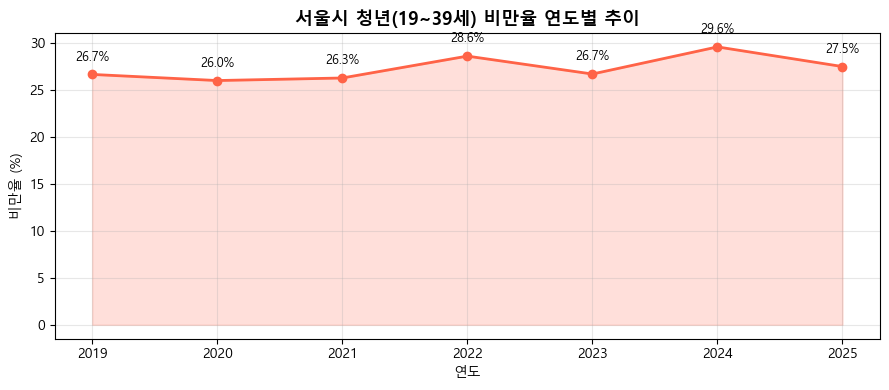

In [22]:
# 연도별 비만율 추이 (간단 확인용)
year_trend = df_final.groupby('year')['비만여부'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(year_trend.index, year_trend.values, 'o-', linewidth=2, color='tomato')
ax.fill_between(year_trend.index, year_trend.values, alpha=0.2, color='tomato')
ax.set_title('서울시 청년(19~39세) 비만율 연도별 추이', fontsize=13, fontweight='bold')
ax.set_xlabel('연도')
ax.set_ylabel('비만율 (%)')
ax.grid(alpha=0.3)
for x, y in zip(year_trend.index, year_trend.values):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_obesity_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📌 다음 단계
- `seoul_youth_individual.csv` (45,621행) → 로지스틱 회귀·의사결정트리·연관성 분석
- `seoul_youth_district_year.csv` (175행) → 클러스터링·선형 회귀
- **체육시설 데이터(자치구별 집계) 결합 → 가설 H2 검증**
- **(선택) 카드매출 배달업종 데이터로 H1 보강**